# 🧠 Notebook 2: CLIPSeg Fine-Tuning + Evaluation
## Prompted Segmentation for Drywall QA

This notebook **fine-tunes CLIPSeg** on both drywall datasets and evaluates performance.

### What this notebook does:
1. Loads the unified dataset prepared in Notebook 1
2. Builds a PyTorch Dataset + DataLoader for text-conditioned segmentation
3. Loads pretrained `CIDAS/clipseg-rd64-refined` from HuggingFace
4. Fine-tunes with BCE + Dice loss
5. Evaluates on validation set every epoch (mIoU, Dice per prompt)
6. Runs final evaluation on test set
7. Saves prediction masks in required format: `{id}__segment_crack.png`
8. Generates visual report (original | GT | prediction)

### Model: CLIPSeg (`CIDAS/clipseg-rd64-refined`)
- Natively text-conditioned segmentation
- Input: image + text prompt → Output: binary mask
- ~400MB model size, runs on T4/3090/4050

---
> ⚠️ **DEBUG_MODE**: Automatically detected from `dataset_info.json`. Override manually if needed.

In [ ]:
"""from google.colab import drive
drive.mount('/content/drive')"""

In [ ]:
!rm -rf "/content/train"
!rm -rf "/content/test"
!rm -rf "/content/val"


In [ ]:
import zipfile

zip_path = "/content/data.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped successfully")

✅ Unzipped successfully


In [ ]:
#!cp -r /content/drive/MyDrive/data_for_drywall/ /content/data/

In [ ]:
import json
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# =============================================================
# FULL DATA SANITY CHECK
# Run this after Notebook 1 to verify everything is correct
# =============================================================

DATA_ROOT = "./data"

## 🔧 Step 0: Configuration

In [ ]:
# =============================================================
# CONFIGURATION — Edit training hyperparameters here
# =============================================================

# --- PATHS (must match Notebook 1 output) ---
DATA_ROOT   = "./data"
OUTPUT_DIR  = "./outputs"       # predictions + checkpoints saved here
CKPT_DIR    = "./checkpoints"   # model checkpoints saved here

# --- MODEL ---
MODEL_NAME  = "CIDAS/clipseg-rd64-refined"  # best CLIPSeg checkpoint for fine-tuning

# --- TRAINING HYPERPARAMETERS ---
EPOCHS      = 20       # full run; debug mode uses fewer
BATCH_SIZE  = 4        # safe for T4 (16GB) and 4050 (6GB)
LR          = 1e-4     # learning rate
IMG_SIZE    = 352      # CLIPSeg default input size
THRESHOLD   = 0.5      # sigmoid threshold for binary mask
WEIGHT_DECAY= 1e-4

# --- SEED (must match Notebook 1) ---
SEED        = 42

# --- DEBUG OVERRIDE (auto-read from dataset_info.json, override here if needed) ---
DEBUG_MODE_OVERRIDE = None   # None = auto-detect | True/False = manual override
DEBUG_EPOCHS        = 3      # epochs to run in debug mode

# --- LOSS WEIGHTS ---
BCE_WEIGHT  = 0.5      # weight for Binary Cross Entropy loss
DICE_WEIGHT = 0.5      # weight for Dice loss
# Total loss = BCE_WEIGHT * bce_loss + DICE_WEIGHT * dice_loss

print("="*50)
print(f"Model       : {MODEL_NAME}")
print(f"Epochs      : {EPOCHS}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"LR          : {LR}")
print(f"Image size  : {IMG_SIZE}")
print(f"Threshold   : {THRESHOLD}")
print(f"Loss weights: BCE={BCE_WEIGHT} | Dice={DICE_WEIGHT}")
print("="*50)

Model       : CIDAS/clipseg-rd64-refined
Epochs      : 20
Batch size  : 4
LR          : 0.0001
Image size  : 352
Threshold   : 0.5
Loss weights: BCE=0.5 | Dice=0.5


## 📥 Step 1: Install Dependencies

In [ ]:
!pip install -q transformers torch torchvision Pillow numpy matplotlib tqdm
print("✅ All packages installed.")

✅ All packages installed.


## 📚 Step 2: Imports & Reproducibility

In [ ]:
import os
import json
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

# --- Fix all seeds for reproducibility ---
def set_seed(seed: int):
    """
    Sets all relevant random seeds for full reproducibility.

    Args:
        seed (int): The seed value to use across all libraries.

    Returns:
        None
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

# --- Device setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# --- Create output directories ---
for d in [OUTPUT_DIR, CKPT_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)
print(f"✅ Output dirs created.")

✅ Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB
✅ Output dirs created.


## 📋 Step 3: Load Dataset Info from Notebook 1

In [ ]:
# Load dataset_info.json written by Notebook 1
info_path = Path(DATA_ROOT) / "dataset_info.json"
assert info_path.exists(), (
    f"❌ dataset_info.json not found at {info_path}. "
    "Please run Notebook 1 first!"
)

with open(info_path) as f:
    dataset_info = json.load(f)

# Auto-detect debug mode from Notebook 1, unless overridden
if DEBUG_MODE_OVERRIDE is not None:
    DEBUG_MODE = DEBUG_MODE_OVERRIDE
else:
    DEBUG_MODE = dataset_info["debug_mode"]

if DEBUG_MODE:
    EPOCHS = DEBUG_EPOCHS
    print(f"🐛 DEBUG MODE ON — running {EPOCHS} epochs only")

print("\n📋 Dataset info:")
print(json.dumps(dataset_info, indent=2))


📋 Dataset info:
{
  "debug_mode": false,
  "seed": 42,
  "prompts": {
    "taping": "segment taping area",
    "crack": "segment crack"
  },
  "data_root": "./data",
  "notes": {
    "taping": "bbox-derived rectangle masks \u2014 detection dataset limitation",
    "crack": "polygon-derived precise masks \u2014 segmentation dataset"
  },
  "split_counts": {
    "train": 3806,
    "val": 773,
    "test": 244
  }
}


## 🗃️ Step 4: PyTorch Dataset Class

In [ ]:
class DrywallSegDataset(Dataset):
    """
    PyTorch Dataset for text-conditioned segmentation.

    Each item returns:
      - pixel_values : preprocessed image tensor for CLIPSeg
      - input_ids    : tokenized text prompt tensor
      - attention_mask: attention mask for text tokens
      - mask         : ground truth binary mask tensor, shape (1, H, W),
                       float32 values in {0.0, 1.0}
      - image_name   : original filename (for saving predictions)
      - prompt       : raw text prompt string

    Args:
        data_root (str): Root of the unified dataset.
        split (str): One of 'train', 'val', 'test'.
        processor (CLIPSegProcessor): HuggingFace processor for CLIPSeg.
        img_size (int): Target image size (CLIPSeg default: 352).
    """

    def __init__(self, data_root: str, split: str,
                 processor, img_size: int = 352):
        self.img_dir   = Path(data_root) / split / "images"
        self.mask_dir  = Path(data_root) / split / "masks"
        self.processor = processor
        self.img_size  = img_size

        # Load prompt mapping: {image_filename: prompt_text}
        prompt_file = Path(data_root) / split / "prompts.json"
        with open(prompt_file) as f:
            self.prompts = json.load(f)

        # Collect all image files that have a prompt entry
        self.samples = [
            p for p in sorted(self.img_dir.glob("*"))
            if p.name in self.prompts
        ]

        print(f"  {split}: {len(self.samples)} samples loaded")

    def __len__(self) -> int:
        """
        Returns the total number of samples in this split.

        Returns:
            int: Number of (image, mask, prompt) triplets.
        """
        return len(self.samples)

    def __getitem__(self, idx: int) -> dict:
        """
        Loads and preprocesses one sample.

        Args:
            idx (int): Sample index.

        Returns:
            dict with keys:
                'pixel_values'  : torch.Tensor shape (3, H, W), float32
                'input_ids'     : torch.Tensor shape (seq_len,), int64
                'attention_mask': torch.Tensor shape (seq_len,), int64
                'mask'          : torch.Tensor shape (1, img_size, img_size), float32
                'image_name'    : str, original filename
                'prompt'        : str, text prompt
        """
        img_path = self.samples[idx]
        prompt   = self.prompts[img_path.name]

        # Load image (RGB)
        image = Image.open(img_path).convert("RGB")

        # Load corresponding mask, resize to model input size
        mask_path = self.mask_dir / f"{img_path.stem}.png"
        if mask_path.exists():
            mask = Image.open(mask_path).convert("L")
        else:
            mask = Image.new("L", image.size, 0)  # empty mask if missing

        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask = torch.tensor(np.array(mask), dtype=torch.float32) / 255.0
        mask = mask.unsqueeze(0)  # shape: (1, H, W)

        # CLIPSeg processor handles image normalization + text tokenization
        encoding = self.processor(
            text    = [prompt],
            images  = [image],
            return_tensors = "pt",
            padding = "max_length",
            truncation = True
        )

        return {
            "pixel_values"  : encoding["pixel_values"].squeeze(0),
            "input_ids"     : encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "mask"          : mask,
            "image_name"    : img_path.name,
            "prompt"        : prompt
        }


print("✅ Dataset class defined.")

✅ Dataset class defined.


## ⚙️ Step 5: Loss Functions

In [ ]:
def dice_loss(pred: torch.Tensor, target: torch.Tensor,
              smooth: float = 1.0) -> torch.Tensor:
    """
    Computes the Dice loss between predicted and target masks.

    Dice loss = 1 - (2 * |pred ∩ target| + smooth) / (|pred| + |target| + smooth)
    Lower is better. Range: [0, 1].

    Args:
        pred (torch.Tensor): Predicted logits or probabilities, shape (B, 1, H, W).
        target (torch.Tensor): Ground truth binary mask, shape (B, 1, H, W),
                               values in {0.0, 1.0}.
        smooth (float): Smoothing factor to avoid division by zero. Default: 1.0.

    Returns:
        torch.Tensor: Scalar Dice loss value.
    """
    pred   = torch.sigmoid(pred)
    pred   = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def combined_loss(pred: torch.Tensor, target: torch.Tensor,
                  bce_w: float = 0.5, dice_w: float = 0.5) -> torch.Tensor:
    """
    Combines Binary Cross Entropy and Dice loss.

    Using both losses together helps:
      - BCE: penalizes pixel-level errors uniformly
      - Dice: focuses on overlap, handles class imbalance better
    This combination is standard practice for segmentation tasks.

    Args:
        pred (torch.Tensor): Raw model logits, shape (B, 1, H, W).
        target (torch.Tensor): Ground truth mask, shape (B, 1, H, W),
                               float32 values in {0.0, 1.0}.
        bce_w (float): Weight for BCE loss component. Default: 0.5.
        dice_w (float): Weight for Dice loss component. Default: 0.5.

    Returns:
        torch.Tensor: Scalar combined loss value.
    """
    bce  = F.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    return bce_w * bce + dice_w * dice


print("✅ Loss functions defined.")

✅ Loss functions defined.


## 📏 Step 6: Evaluation Metrics

In [ ]:
def compute_iou(pred_mask: np.ndarray, gt_mask: np.ndarray) -> float:
    """
    Computes Intersection over Union (IoU) between predicted and GT masks.

    IoU = |pred ∩ gt| / |pred ∪ gt|
    Range: [0.0, 1.0]. Higher is better.

    Args:
        pred_mask (np.ndarray): Binary predicted mask, shape (H, W),
                                dtype bool or uint8, values {0, 1}.
        gt_mask (np.ndarray): Binary ground truth mask, same shape and dtype.

    Returns:
        float: IoU score. Returns 1.0 if both masks are empty (true negative).
    """
    pred_bool = pred_mask.astype(bool)
    gt_bool   = gt_mask.astype(bool)

    intersection = np.logical_and(pred_bool, gt_bool).sum()
    union        = np.logical_or(pred_bool, gt_bool).sum()

    if union == 0:
        return 1.0  # both empty = perfect true negative
    return float(intersection) / float(union)


def compute_dice(pred_mask: np.ndarray, gt_mask: np.ndarray) -> float:
    """
    Computes the Dice coefficient (F1 score for segmentation) between
    predicted and ground truth masks.

    Dice = 2 * |pred ∩ gt| / (|pred| + |gt|)
    Range: [0.0, 1.0]. Higher is better.

    Args:
        pred_mask (np.ndarray): Binary predicted mask, shape (H, W),
                                values {0, 1}.
        gt_mask (np.ndarray): Binary ground truth mask, same shape.

    Returns:
        float: Dice score. Returns 1.0 if both masks are empty.
    """
    pred_bool = pred_mask.astype(bool)
    gt_bool   = gt_mask.astype(bool)

    intersection = np.logical_and(pred_bool, gt_bool).sum()
    total        = pred_bool.sum() + gt_bool.sum()

    if total == 0:
        return 1.0
    return float(2 * intersection) / float(total)


def evaluate_split(model, dataloader, device, threshold: float = 0.5) -> dict:
    """
    Runs evaluation on an entire split and returns per-prompt and overall metrics.

    Computes mIoU and mean Dice score, broken down by prompt type.

    Args:
        model: Fine-tuned CLIPSegForImageSegmentation model.
        dataloader: DataLoader for the split to evaluate.
        device: torch.device ('cuda' or 'cpu').
        threshold (float): Sigmoid threshold for converting logits → binary mask.
                           Default: 0.5.

    Returns:
        dict: {
            'overall'    : {'mIoU': float, 'Dice': float},
            'per_prompt' : {prompt_str: {'mIoU': float, 'Dice': float, 'n': int}}
        }
    """
    model.eval()
    per_prompt = {}  # {prompt: {'ious': [], 'dices': []}}

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="  Evaluating", leave=False):
            pixel_values   = batch["pixel_values"].to(device)
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            gt_masks       = batch["mask"].cpu().numpy()  # (B, 1, H, W)
            prompts        = batch["prompt"]

            outputs = model(
                pixel_values   = pixel_values,
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

            # CLIPSeg output logits: shape (B, H, W)
            logits = outputs.logits  # (B, H, W)
            probs  = torch.sigmoid(logits).cpu().numpy()  # (B, H, W)

            for i in range(len(prompts)):
                pred_bin = (probs[i] > threshold).astype(np.uint8)  # (H, W)
                gt_bin   = (gt_masks[i, 0] > 0.5).astype(np.uint8) # (H, W)

                iou  = compute_iou(pred_bin, gt_bin)
                dice = compute_dice(pred_bin, gt_bin)

                p = prompts[i]
                if p not in per_prompt:
                    per_prompt[p] = {'ious': [], 'dices': []}
                per_prompt[p]['ious'].append(iou)
                per_prompt[p]['dices'].append(dice)

    # Aggregate
    result = {'per_prompt': {}, 'overall': {}}
    all_ious, all_dices = [], []

    for p, vals in per_prompt.items():
        m_iou  = float(np.mean(vals['ious']))
        m_dice = float(np.mean(vals['dices']))
        result['per_prompt'][p] = {
            'mIoU': round(m_iou, 4),
            'Dice': round(m_dice, 4),
            'n'   : len(vals['ious'])
        }
        all_ious.extend(vals['ious'])
        all_dices.extend(vals['dices'])

    result['overall'] = {
        'mIoU': round(float(np.mean(all_ious)), 4),
        'Dice': round(float(np.mean(all_dices)), 4)
    }

    return result


print("✅ Evaluation metrics defined.")

✅ Evaluation metrics defined.


## 🔄 Step 7: Load Model + Build DataLoaders

In [ ]:
print(f"⬇️  Loading CLIPSeg processor and model: {MODEL_NAME}")
t0 = time.time()

processor = CLIPSegProcessor.from_pretrained(MODEL_NAME)
model     = CLIPSegForImageSegmentation.from_pretrained(MODEL_NAME)
model     = model.to(DEVICE)

load_time = time.time() - t0
print(f"✅ Model loaded in {load_time:.1f}s")

# Model size
n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total params     : {n_params/1e6:.1f}M")
print(f"   Trainable params : {n_train/1e6:.1f}M")

# Build datasets
print("\n📂 Building datasets...")
train_ds = DrywallSegDataset(DATA_ROOT, "train", processor, IMG_SIZE)
val_ds   = DrywallSegDataset(DATA_ROOT, "val",   processor, IMG_SIZE)
test_ds  = DrywallSegDataset(DATA_ROOT, "test",  processor, IMG_SIZE)

# Build dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\n✅ DataLoaders ready:")
print(f"   Train : {len(train_ds)} samples, {len(train_loader)} batches")
print(f"   Val   : {len(val_ds)} samples, {len(val_loader)} batches")
print(f"   Test  : {len(test_ds)} samples, {len(test_loader)} batches")

⬇️  Loading CLIPSeg processor and model: CIDAS/clipseg-rd64-refined


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded in 21.4s
   Total params     : 150.7M
   Trainable params : 150.7M

📂 Building datasets...
  train: 3806 samples loaded
  val: 743 samples loaded
  test: 244 samples loaded

✅ DataLoaders ready:
   Train : 3806 samples, 952 batches
   Val   : 743 samples, 186 batches
   Test  : 244 samples, 61 batches


## 🏋️ Step 8: Training Loop

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

# Training history (for plotting later)
history = {
    'train_loss': [],
    'val_mIoU'  : [],
    'val_Dice'  : []
}

best_val_iou  = 0.0
best_ckpt     = Path(CKPT_DIR) / "best_model.pt"

print(f"🏋️  Starting training for {EPOCHS} epochs...\n")
total_train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # ============================================================
    # TRAIN
    # ============================================================
    model.train()
    epoch_losses = []
    epoch_start  = time.time()

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        pixel_values   = batch["pixel_values"].to(DEVICE)
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        gt_masks       = batch["mask"].to(DEVICE)  # (B, 1, H, W)

        optimizer.zero_grad()

        outputs = model(
            pixel_values   = pixel_values,
            input_ids      = input_ids,
            attention_mask = attention_mask
        )

        # CLIPSeg returns logits of shape (B, H, W) — add channel dim
        logits = outputs.logits.unsqueeze(1)  # (B, 1, H, W)

        # Resize GT mask to match logit spatial size if needed
        if logits.shape[-2:] != gt_masks.shape[-2:]:
            gt_masks = F.interpolate(gt_masks, size=logits.shape[-2:],
                                     mode='nearest')

        loss = combined_loss(logits, gt_masks,
                              bce_w=BCE_WEIGHT, dice_w=DICE_WEIGHT)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    scheduler.step()

    avg_loss = np.mean(epoch_losses)
    history['train_loss'].append(avg_loss)

    # ============================================================
    # VALIDATE
    # ============================================================
    val_metrics = evaluate_split(model, val_loader, DEVICE, THRESHOLD)
    val_iou     = val_metrics['overall']['mIoU']
    val_dice    = val_metrics['overall']['Dice']

    history['val_mIoU'].append(val_iou)
    history['val_Dice'].append(val_dice)

    epoch_time = time.time() - epoch_start

    print(f"  Epoch {epoch:3d}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Val mIoU: {val_iou:.4f} | "
          f"Val Dice: {val_dice:.4f} | "
          f"Time: {epoch_time:.0f}s")

    # Per-prompt breakdown every 5 epochs
    if epoch % 5 == 0 or epoch == EPOCHS:
        print("  Per-prompt val metrics:")
        for p, m in val_metrics['per_prompt'].items():
            print(f"    '{p}': mIoU={m['mIoU']:.4f} | Dice={m['Dice']:.4f} | n={m['n']}")

    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), best_ckpt)
        print(f"  💾 Best model saved (val mIoU: {best_val_iou:.4f})")

total_train_time = time.time() - total_train_start
print(f"\n✅ Training complete in {total_train_time/60:.1f} min")
print(f"   Best val mIoU: {best_val_iou:.4f}")
print(f"   Checkpoint   : {best_ckpt}")

🏋️  Starting training for 20 epochs...



Epoch 1/20 [train]: 100%|██████████| 952/952 [02:43<00:00,  5.83it/s]


  Epoch   1/20 | Loss: 0.3846 | Val mIoU: 0.5727 | Val Dice: 0.6972 | Time: 194s
  💾 Best model saved (val mIoU: 0.5727)


Epoch 2/20 [train]: 100%|██████████| 952/952 [02:43<00:00,  5.82it/s]


  Epoch   2/20 | Loss: 0.2995 | Val mIoU: 0.6153 | Val Dice: 0.7354 | Time: 194s
  💾 Best model saved (val mIoU: 0.6153)


...

  Epoch  18/20 | Loss: 0.1619 | Val mIoU: 0.6621 | Val Dice: 0.7694 | Time: 194s


Epoch 19/20 [train]: 100%|██████████| 952/952 [02:45<00:00,  5.74it/s]


  Epoch  19/20 | Loss: 0.1604 | Val mIoU: 0.6616 | Val Dice: 0.7689 | Time: 197s


Epoch 20/20 [train]: 100%|██████████| 952/952 [02:44<00:00,  5.78it/s]
                                                               

  Epoch  20/20 | Loss: 0.1599 | Val mIoU: 0.6625 | Val Dice: 0.7697 | Time: 196s
  Per-prompt val metrics:
    'segment crack': mIoU=0.7339 | Dice=0.8325 | n=523
    'segment taping area': mIoU=0.4929 | Dice=0.6205 | n=220

✅ Training complete in 65.3 min
   Best val mIoU: 0.6651
   Checkpoint   : checkpoints/best_model.pt


## 📈 Step 9: Plot Training Curves

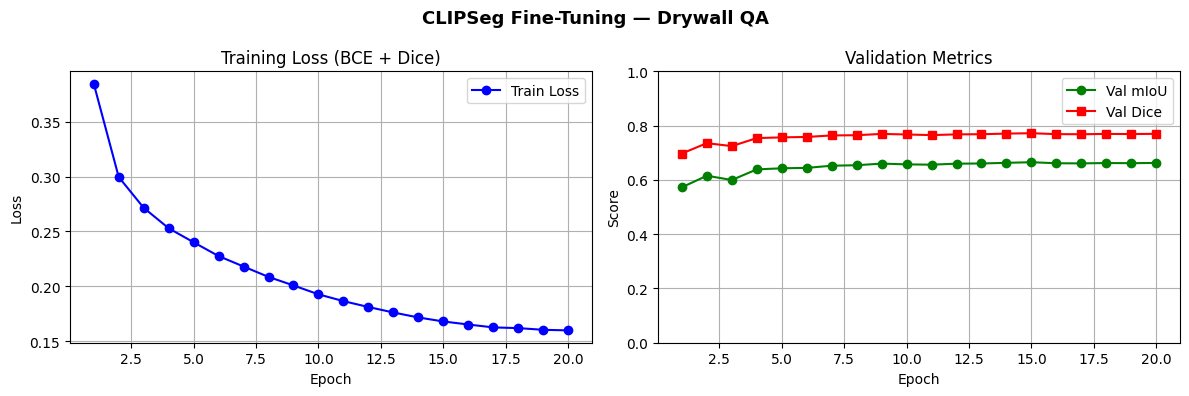

✅ Training curves saved to ./outputs/training_curves.png


In [ ]:
def plot_training_curves(history: dict, save_path: str):
    """
    Plots training loss and validation metrics (mIoU, Dice) over epochs.

    Args:
        history (dict): Training history with keys:
                        'train_loss', 'val_mIoU', 'val_Dice'.
                        Each value is a list of per-epoch scalar values.
        save_path (str): File path to save the plot as PNG.

    Returns:
        None (displays and saves the figure)
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[0].set_title('Training Loss (BCE + Dice)')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history['val_mIoU'], 'g-o', label='Val mIoU')
    axes[1].plot(epochs, history['val_Dice'], 'r-s', label='Val Dice')
    axes[1].set_title('Validation Metrics')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].legend(); axes[1].grid(True)
    axes[1].set_ylim([0, 1])

    plt.suptitle('CLIPSeg Fine-Tuning — Drywall QA', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✅ Training curves saved to {save_path}")


plot_training_curves(history, f"{OUTPUT_DIR}/training_curves.png")

## 🧪 Step 10: Final Test Set Evaluation

In [ ]:
# Load best checkpoint for final evaluation
print("📂 Loading best checkpoint for test evaluation...")
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))

print("🧪 Running final test set evaluation...")
test_metrics = evaluate_split(model, test_loader, DEVICE, THRESHOLD)

print("\n" + "="*55)
print("FINAL TEST RESULTS")
print("="*55)
print(f"Overall mIoU : {test_metrics['overall']['mIoU']:.4f}")
print(f"Overall Dice : {test_metrics['overall']['Dice']:.4f}")
print("\nPer-prompt breakdown:")
for p, m in test_metrics['per_prompt'].items():
    print(f"  '{p}'")
    print(f"     mIoU : {m['mIoU']:.4f}")
    print(f"     Dice : {m['Dice']:.4f}")
    print(f"     n    : {m['n']}")
print("="*55)

# Save metrics JSON
metrics_out = Path(OUTPUT_DIR) / "test_metrics.json"
with open(metrics_out, 'w') as f:
    json.dump(test_metrics, f, indent=2)
print(f"\n✅ Test metrics saved to {metrics_out}")

📂 Loading best checkpoint for test evaluation...
🧪 Running final test set evaluation...



FINAL TEST RESULTS
Overall mIoU : 0.6900
Overall Dice : 0.7957

Per-prompt breakdown:
  'segment crack'
     mIoU : 0.6900
     Dice : 0.7957
     n    : 244

✅ Test metrics saved to outputs/test_metrics.json


## 💾 Step 11: Save Prediction Masks (Required Format)

In [ ]:
def save_prediction_masks(model, dataloader, device: torch.device,
                           out_dir: str, threshold: float = 0.5):
    """
    Generates and saves prediction masks for all images in the given dataloader.

    Output filename format (as required by the assignment):
        {image_stem}__{prompt_underscored}.png
    Example: 'tape_img001__segment_taping_area.png'

    Mask format:
        - Single-channel PNG
        - Same spatial size as source image
        - Pixel values: 0 (background) or 255 (foreground)

    Args:
        model: Fine-tuned CLIPSeg model in eval mode.
        dataloader: DataLoader for the dataset to predict on.
        device (torch.device): Device to run inference on.
        out_dir (str): Directory to save prediction masks.
        threshold (float): Sigmoid threshold for binarization. Default: 0.5.

    Returns:
        tuple: (count of saved masks, average inference time per image in ms)
    """
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    model.eval()
    saved = 0
    times = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="  Saving prediction masks"):
            pixel_values   = batch["pixel_values"].to(device)
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            image_names    = batch["image_name"]
            prompts_batch  = batch["prompt"]

            t_start = time.time()
            outputs = model(
                pixel_values   = pixel_values,
                input_ids      = input_ids,
                attention_mask = attention_mask
            )
            t_end = time.time()
            times.append((t_end - t_start) / len(image_names) * 1000)  # ms/image

            probs = torch.sigmoid(outputs.logits).cpu().numpy()  # (B, H, W)

            for i in range(len(image_names)):
                pred_bin  = ((probs[i] > threshold) * 255).astype(np.uint8)
                stem      = Path(image_names[i]).stem
                prompt_fn = prompts_batch[i].replace(" ", "_")  # e.g. 'segment_crack'
                fname     = f"{stem}__{prompt_fn}.png"

                Image.fromarray(pred_bin, mode='L').save(Path(out_dir) / fname)
                saved += 1

    avg_inf_ms = float(np.mean(times))
    print(f"  ✅ {saved} masks saved to {out_dir}")
    print(f"  ⏱️  Avg inference: {avg_inf_ms:.1f} ms/image")
    return saved, avg_inf_ms



pred_dir = Path(OUTPUT_DIR) / "predictions"

print("💾 Saving prediction masks for test set...")
n_saved, avg_ms = save_prediction_masks(
    model, test_loader, DEVICE, str(pred_dir), THRESHOLD
)

💾 Saving prediction masks for test set...


  Saving prediction masks:   0%|          | 0/61 [00:00<?, ?it/s]/tmp/ipykernel_2607/1340544351.py:55: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(pred_bin, mode='L').save(Path(out_dir) / fname)
  Saving prediction masks: 100%|██████████| 61/61 [00:10<00:00,  5.71it/s]

  ✅ 244 masks saved to outputs/predictions
  ⏱️  Avg inference: 13.0 ms/image


## 🖼️ Step 12: Visual Report — Original | GT | Prediction

✅ Visual report saved to ./outputs/visual_report.png


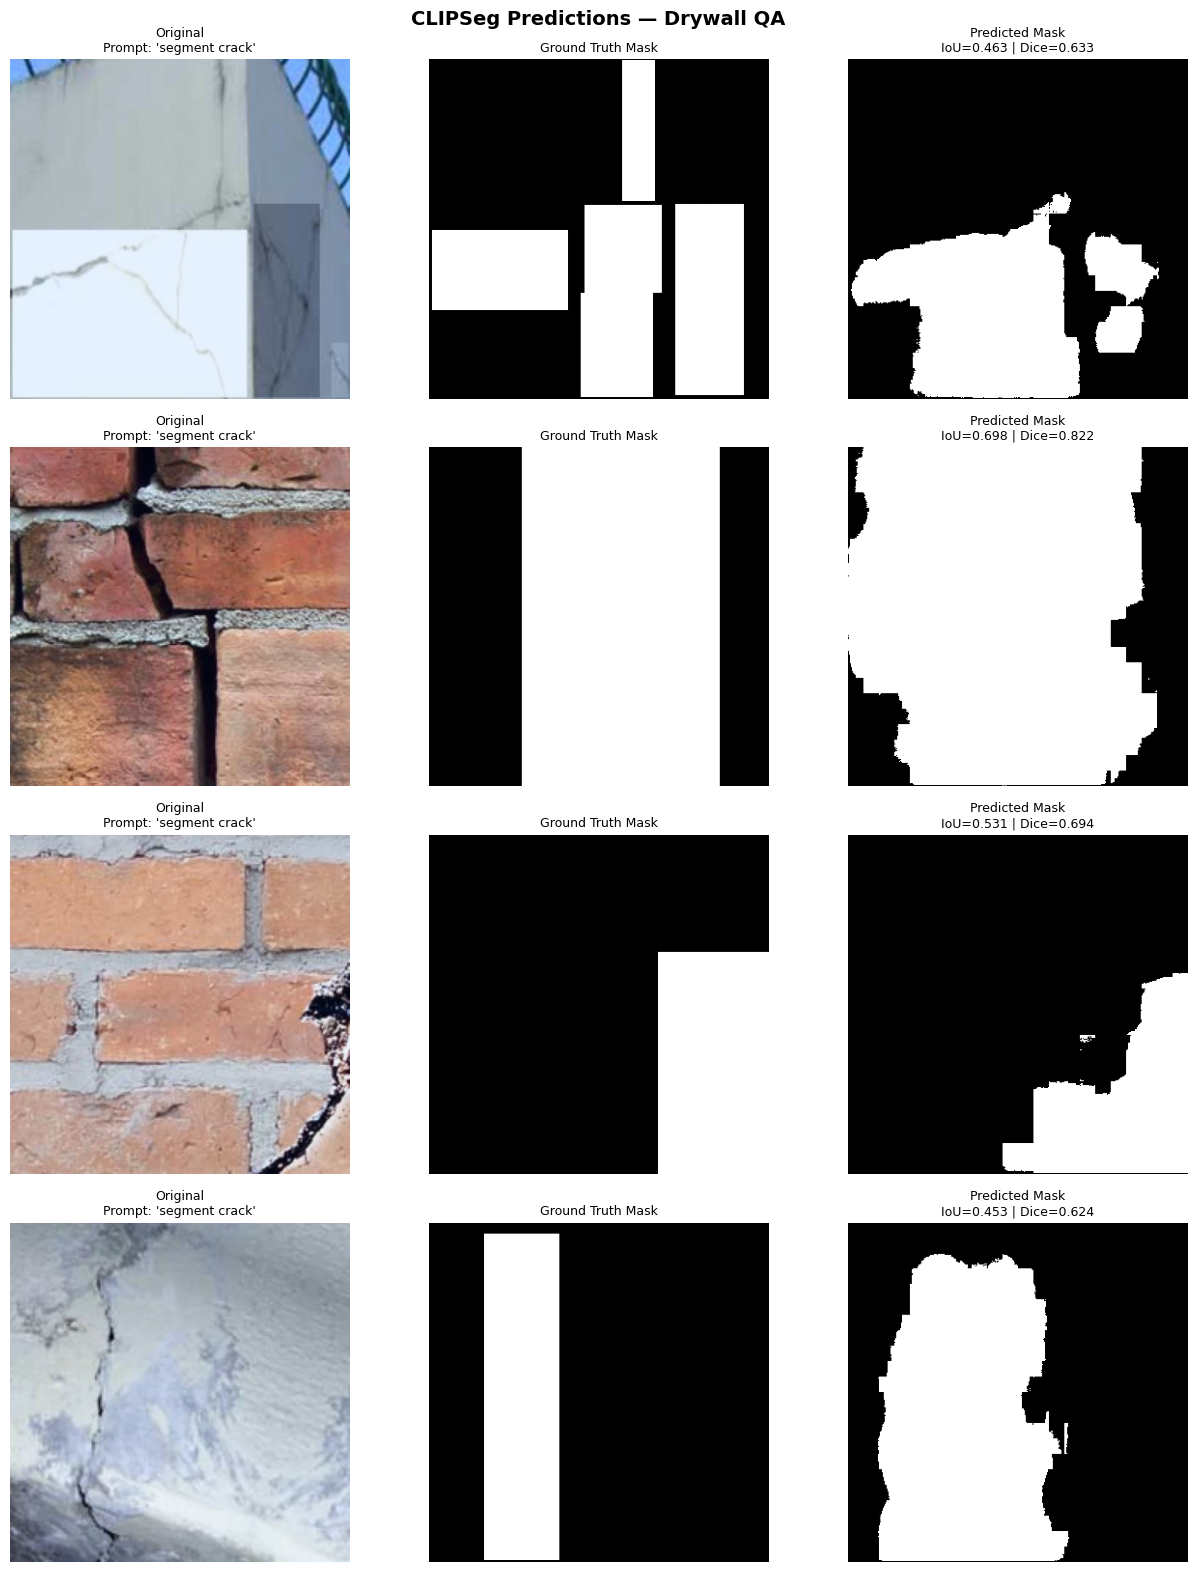

In [ ]:
def visualize_predictions(model, dataset, device: torch.device,
                           n_samples: int = 4, threshold: float = 0.5,
                           save_path: str = None, seed: int = 42):
    """
    Displays a visual comparison grid: Original Image | GT Mask | Predicted Mask.
    Samples are randomly selected from the dataset.
    This is the visual report required in the assignment rubric.

    Args:
        model: Fine-tuned CLIPSeg model.
        dataset (DrywallSegDataset): Dataset to sample from.
        device (torch.device): Device for inference.
        n_samples (int): Number of samples to display. Default: 4.
        threshold (float): Binarization threshold. Default: 0.5.
        save_path (str): If provided, saves the figure as PNG.
        seed (int): Random seed for sample selection.

    Returns:
        None (displays matplotlib figure)
    """
    random.seed(seed)
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))

    model.eval()
    fig, axes = plt.subplots(n_samples, 3, figsize=(13, 4 * n_samples))
    if n_samples == 1:
        axes = [axes]

    with torch.no_grad():
        for row, idx in enumerate(indices):
            sample = dataset[idx]

            # Run inference
            pv = sample["pixel_values"].unsqueeze(0).to(device)
            ii = sample["input_ids"].unsqueeze(0).to(device)
            am = sample["attention_mask"].unsqueeze(0).to(device)

            out   = model(pixel_values=pv, input_ids=ii, attention_mask=am)
            prob  = torch.sigmoid(out.logits[0]).cpu().numpy()  # (H, W)
            pred  = (prob > threshold).astype(np.uint8) * 255

            # Ground truth
            gt    = (sample["mask"][0].numpy() > 0.5).astype(np.uint8) * 255

            # Original image (de-normalize CLIPSeg pixel values)
            img_t = sample["pixel_values"].numpy()  # (3, H, W)
            img_t = np.transpose(img_t, (1, 2, 0))  # (H, W, 3)
            img_t = (img_t - img_t.min()) / (img_t.max() - img_t.min() + 1e-8)

            prompt = sample["prompt"]
            iou    = compute_iou(pred // 255, gt // 255)
            dice   = compute_dice(pred // 255, gt // 255)

            axes[row][0].imshow(img_t)
            axes[row][0].set_title(f"Original\nPrompt: '{prompt}'", fontsize=9)

            axes[row][1].imshow(gt, cmap='gray', vmin=0, vmax=255)
            axes[row][1].set_title("Ground Truth Mask", fontsize=9)

            axes[row][2].imshow(pred, cmap='gray', vmin=0, vmax=255)
            axes[row][2].set_title(
                f"Predicted Mask\nIoU={iou:.3f} | Dice={dice:.3f}", fontsize=9
            )

            for ax in axes[row]:
                ax.axis('off')

    plt.suptitle("CLIPSeg Predictions — Drywall QA", fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"✅ Visual report saved to {save_path}")
    plt.show()


visualize_predictions(
    model, test_ds, DEVICE,
    n_samples  = 4,
    threshold  = THRESHOLD,
    save_path  = f"{OUTPUT_DIR}/visual_report.png",
    seed       = SEED
)

## 📊 Step 13: Final Summary Report

In [ ]:
# Compute model size on disk
ckpt_size_mb = os.path.getsize(best_ckpt) / (1024 * 1024)

print("\n" + "="*60)
print("📋  FINAL SUMMARY REPORT")
print("="*60)
print(f"Model           : {MODEL_NAME}")
print(f"Total params    : {n_params/1e6:.1f}M")
print(f"Model size      : {ckpt_size_mb:.0f} MB")
print(f"Seed            : {SEED}")
print(f"Debug mode      : {DEBUG_MODE}")
print(f"Epochs trained  : {EPOCHS}")
print(f"Total train time: {total_train_time/60:.1f} min")
print(f"Avg inference   : {avg_ms:.1f} ms/image")
print("")
print(f"{'─'*60}")
print(f"{'METRIC':<30} {'VALUE':>10}")
print(f"{'─'*60}")
print(f"{'Test mIoU (overall)':<30} {test_metrics['overall']['mIoU']:>10.4f}")
print(f"{'Test Dice (overall)':<30} {test_metrics['overall']['Dice']:>10.4f}")
for p, m in test_metrics['per_prompt'].items():
    print(f"{'─'*60}")
    print(f"  Prompt: '{p}'")
    print(f"  {'mIoU':<28} {m['mIoU']:>10.4f}")
    print(f"  {'Dice':<28} {m['Dice']:>10.4f}")
    print(f"  {'n samples':<28} {m['n']:>10}")
print(f"{'='*60}")

# Save full summary
summary = {
    "model"             : MODEL_NAME,
    "total_params_M"    : round(n_params/1e6, 1),
    "model_size_MB"     : round(ckpt_size_mb, 1),
    "seed"              : SEED,
    "debug_mode"        : DEBUG_MODE,
    "epochs"            : EPOCHS,
    "train_time_min"    : round(total_train_time/60, 2),
    "avg_inference_ms"  : round(avg_ms, 2),
    "test_metrics"      : test_metrics,
    "best_val_mIoU"     : round(best_val_iou, 4)
}

summary_path = Path(OUTPUT_DIR) / "final_summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ Summary saved to {summary_path}")
print("\n🎉 Notebook 2 complete! All outputs in:", OUTPUT_DIR)


📋  FINAL SUMMARY REPORT
Model           : CIDAS/clipseg-rd64-refined
Total params    : 150.7M
Model size      : 575 MB
Seed            : 42
Debug mode      : False
Epochs trained  : 20
Total train time: 65.3 min
Avg inference   : 13.0 ms/image

────────────────────────────────────────────────────────────
METRIC                              VALUE
────────────────────────────────────────────────────────────
Test mIoU (overall)                0.6900
Test Dice (overall)                0.7957
────────────────────────────────────────────────────────────
  Prompt: 'segment crack'
  mIoU                             0.6900
  Dice                             0.7957
  n samples                           244

✅ Summary saved to outputs/final_summary.json

🎉 Notebook 2 complete! All outputs in: ./outputs


In [ ]:
import shutil

folder_path = "/content/outputs"
zip_path = "/content/outputs"

shutil.make_archive(zip_path, 'zip', folder_path)

print("✅ Zipped successfully")


✅ Zipped successfully
